In [1]:
from tqdm import tqdm
import numpy as np
import os
import cv2
import concurrent.futures
from scipy.interpolate import splprep, splev
import networkx as nx
from scipy.spatial import distance_matrix

def display_images_with_bbox(images):
    image = images[0]
    images = images[::int(len(images)/10)]
    # Select ROI 
    r = cv2.selectROI("select the area", image) 
    cv2.waitKey(0) 
    cv2.destroyAllWindows()
    return (int(r[1]), int(r[1]+r[3]), int(r[0]), int(r[0]+r[2]))

def load_images_from_directory(directory):
    files = sorted([os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(('png', 'jpg', 'jpeg'))])
    print("loading images...")
    images = [cv2.imread(file) for file in tqdm(files)]
    return images

def sum_intersections(region, past_regions):
    region_hull = cv2.convexHull(np.array(region))
    return sum(cv2.intersectConvexConvex(region_hull, cv2.convexHull(np.array(r)))[0]/cv2.contourArea(cv2.convexHull(np.array(r))) for r in past_regions)   


def denoise_and_crop(image,bbox):
    image = cv2.normalize(image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    image = cv2.fastNlMeansDenoisingColored(image,None,25,15,7,21)
    image = cv2.bilateralFilter(image, 15, 75, 75) 
    return image

def denoise_and_crop_images(images, bbox):
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = [executor.submit(denoise_and_crop, image, bbox) for image in images]
        results = [future.result() for future in tqdm(futures, total=len(futures))]

    return (
        [result[bbox[0]:bbox[1], bbox[2]:bbox[3]] for result in results],
        [image[bbox[0]:bbox[1], bbox[2]:bbox[3]] for image in images],
        results,
    )

def process(image, original_image = None, n = 20, past_regions = None):

    if original_image is None:
        result = image.copy()
    else:
        result = original_image

    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    image_area = image.shape[0]*image.shape[1]
    mser = cv2.MSER_create(delta=2, min_area=image_area//64, max_area=image_area//8, max_variation=1, min_diversity=0.1)

    regions, _ = mser.detectRegions(gray)

    if past_regions is not None:
        regions = sorted(regions, key=lambda region : sum_intersections(region, past_regions), reverse=True)
    else:
        regions = sorted(regions, key=cv2.contourArea, reverse=True)

    if len(regions) == 0:
         regions = past_regions
         
    if len(regions) != 0:
        hull = cv2.convexHull(regions[0].reshape(-1, 1, 2))
        cv2.drawContours(result, [hull], 0, (0, 0, 255), 1)

        aux_image = np.zeros_like(gray)
        cv2.fillPoly(aux_image, [regions[0]], 255)
        coords = track_image(aux_image)
        for coord in coords:
            result[int(coord[0]),int(coord[1])]=[255,0,0]

    return result, regions[:n], coords

def track_image(aux_image):
    skeleton = cv2.ximgproc.thinning(cv2.threshold(aux_image,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1])
    coordinates = np.argwhere(skeleton == 255)
    return coordinates

        
image_dir = '/home/yuming/Documents/mt_data/MT10_30min_200x_1500_138_146pm'
output_video = '/home/yuming/Documents/dev/python/projects/microtuble-tracking/output_video_4.mp4'
rough_coordinates_file = '/home/yuming/Documents/dev/python/projects/microtubule-tracking-2/rough_coordinates.txt'





In [2]:
raw_images = load_images_from_directory(image_dir)
bbox = (81, 259, 103, 517)


print(bbox)

loading images...


100%|██████████| 1500/1500 [00:06<00:00, 219.48it/s]

(81, 259, 103, 517)


In [3]:
f = open(rough_coordinates_file, "w")
f.write(f"bbox_shape {bbox}")
f.close()
images, original_images, images_uncropped = denoise_and_crop_images(raw_images, bbox)


100%|██████████| 1500/1500 [02:30<00:00,  9.97it/s]


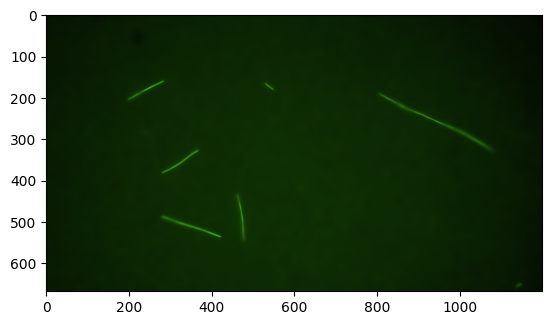

In [4]:
import matplotlib.pyplot as plt
plt.imshow(images_uncropped[1])

In [5]:
def add_number_to_image(image, number, font_scale=1, color=(255, 255, 255), thickness=2, padding=10):
    font = cv2.FONT_HERSHEY_SIMPLEX

    text = str(number)
    height, width = image.shape[:2]
    (text_width, text_height), _ = cv2.getTextSize(text, font, font_scale, thickness)
    x = width - text_width - padding  # X position
    y = height - padding  # Y position (slightly above the bottom edge)
    cv2.putText(image, text, (x, y), font, font_scale, color, thickness)
    return image

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video = cv2.VideoWriter(output_video, fourcc, 30, (images[0].shape[1],images[0].shape[0]))

regions = None
print("processing and writing to video...")
with open(rough_coordinates_file, 'a') as file:
    for i, image in enumerate(tqdm(images)):
        image, regions, coords = process(image, original_image = original_images[i], past_regions=regions)
        image = add_number_to_image(image, i)
        video.write(image)
        for j, (x, y) in enumerate(coords):
            file.write(f"{i}\t{j}\t{x}\t{y}\t0\n")


# Release the video writer
video.release()
print(f"Video saved as {output_video}")


processing and writing to video...


100%|██████████| 1500/1500 [00:07<00:00, 214.28it/s]

Video saved as /home/yuming/Documents/dev/python/projects/microtuble-tracking/output_video_4.mp4


/tmp/ipykernel_7793/3236812128.py:18: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


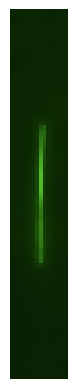

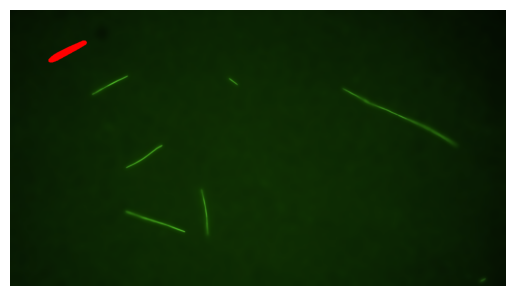

In [28]:
import matplotlib.pyplot as plt

def extract_rotated_region(image, region,  e=1):

    region = region.T
    x, y, w, h = enlarge_bounding_box(region, e)
    enlarged_region = np.zeros_like(region)
    enlarged_region[y:y+h, x:x+w] = region[y:y+h, x:x+w]
    points = np.column_stack(np.where(enlarged_region > 0))
    rect = cv2.minAreaRect(points)

    tempvar = rect[2]
    if rect[1][0] > rect[1][1]:
        rect = ((rect[0][0], rect[0][1]), (rect[1][1], rect[1][0]), rect[2]+90)
    box = cv2.boxPoints(rect)
    center = np.mean(box, axis=0)
    box = e * (box - center) + center
    box = np.int0(box)
    width, height = int(rect[1][0]), int(rect[1][1])
    src_pts = box.astype("float32")
    dst_pts = np.array([[0, height-1], [0, 0], [width-1, 0], [width-1, height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    return cv2.warpPerspective(image, M, (width, height)), (src_pts, dst_pts), tempvar, box


def enlarge_bounding_box(region, e=2):
    x, y, w, h = cv2.boundingRect(region)
    cx, cy = x + w / 2, y + h / 2
    w_enlarged, h_enlarged = w * e, h * e
    x_new, y_new = int(cx - w_enlarged / 2), int(cy - h_enlarged / 2)
    w_new, h_new = int(w_enlarged), int(h_enlarged)
    
    return (x_new, y_new, w_new, h_new)

def process_box(image, raw_image, original_image = None, n = 20, past_regions = None, factor = 2):


    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    image_area = image.shape[0]*image.shape[1]
    mser = cv2.MSER_create(delta=2, min_area=image_area//64, max_area=image_area//8, max_variation=1, min_diversity=0.1)

    regions, _ = mser.detectRegions(gray)

    if past_regions is not None:
        regions = sorted(regions, key=lambda region : sum_intersections(region, past_regions), reverse=True)
    else:
        regions = sorted(regions, key=cv2.contourArea, reverse=True)

    if len(regions) == 0:
         regions = past_regions


    
    points = regions[0]+np.vstack((np.full(regions[0].shape[0],bbox[2]),np.full(regions[0].shape[0],bbox[0]))).T
    shape = (raw_image.shape[1],raw_image.shape[0])
    

    region = np.zeros(shape, dtype=np.uint8)
    y, x = zip(*points)
    region[x,y] = 1 
    result, sd_points, angle, box = extract_rotated_region(raw_image, region, e=2.5)

    return result, regions[:n], sd_points, angle, box

def perspective_transform_point(src_points, dst_points, point, inverse=True):
    matrix = cv2.getPerspectiveTransform(src_points, dst_points)
    if inverse:
        matrix = np.linalg.inv(matrix)
    px, py = point
    transformed_point = matrix @ [px, py, 1]
    transformed_point /= transformed_point[2]
    return transformed_point[:2]

output1, output2, output3, _, box = process_box(images[1],images_uncropped[1],factor=1)
plt.axis('off')
plt.imshow(output1)

plt.show()
plt.axis('off')
test = images_uncropped[1].copy()
hull = cv2.convexHull(output2[0].reshape(-1, 1, 2))
cv2.drawContours(test,[hull],0,255,-1)
plt.imshow(test)




  0%|          | 0/1500 [00:00<?, ?it/s]/tmp/ipykernel_7793/3236812128.py:18: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)
100%|██████████| 1500/1500 [00:05<00:00, 266.31it/s]


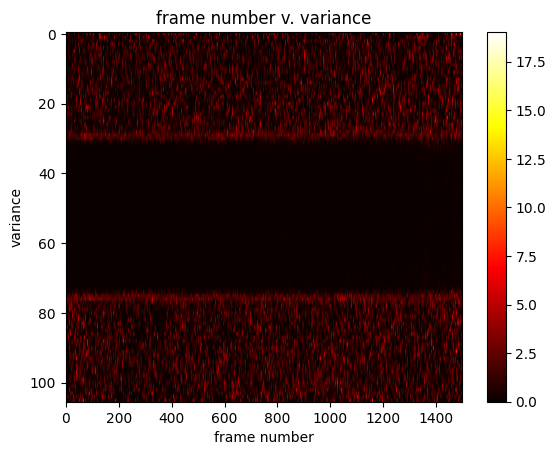

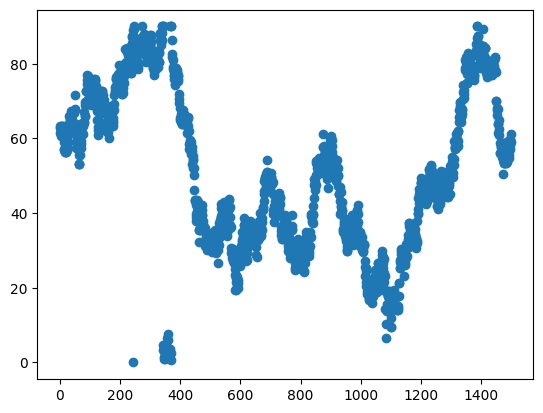

In [29]:

distances = []
coords3 = []
mser_images = []
mser_sd_points = []
regions = []
angles = []
def rough_track(image):
    image = image[:,:,0]
    x = np.argmax(image,axis=1)
    return np.array([x,np.array(list(range(x.shape[0])))])

for i, image in enumerate(tqdm(images)):
    mser_image, regions, sd_points, angle,_ = process_box(image, images_uncropped[i], original_image = None, past_regions=regions)
    coords1 = rough_track(mser_image)
    coords3.append(coords1)
    distances.append(np.linalg.norm(coords1.T[1:] - coords1.T[:-1], axis=1)-1)
    mser_images.append(mser_image)
    mser_sd_points.append(sd_points)
    angles.append(angle)


max_length = max(len(sublist) for sublist in distances)


padded_distances = np.array([np.interp(np.linspace(0, len(d) - 1, max_length),np.arange(len(d)),d) for d in distances])
plt.imshow(np.power(padded_distances.T[:,:],1),cmap='hot',aspect='auto',vmin=0)
plt.colorbar()
plt.xlabel('frame number')
plt.ylabel('variance')
plt.title('frame number v. variance')
plt.show()
plt.scatter(range(len(angles)),angles)

In [6]:
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt


def detect_and_plot_change_points(data, model='l2', penalty=30, show = True):
    algo = rpt.Pelt(model=model).fit(data)
    all_change_points = algo.predict(pen=penalty)
    
    midpoint = len(data) // 2
    greater_cp = None
    lesser_cp = None
    
    for cp in all_change_points:
        if cp > midpoint and (greater_cp is None or cp < greater_cp):
            greater_cp = cp
        elif cp < midpoint and (lesser_cp is None or cp > lesser_cp):
            lesser_cp = cp

    selected_change_points = [lesser_cp, greater_cp]

    if show is True:
        plt.figure(figsize=(10, 6))
        plt.plot(data, label='Time Series Data')
        for cp in selected_change_points:
            plt.axvline(cp, color='red', linestyle='--', label='Change Point' if cp == selected_change_points[0] else "")
        plt.title('Change Point Detection')
        plt.xlabel('Time')
        plt.ylabel('Value')
        plt.legend()
        plt.show()
    
    return selected_change_points

testvar = None

def find_low_center_interval(data, threshold=0.25):
    middle = len(data) // 2

    # Find left boundary
    left_index = next((i for i in range(middle, 0, -1) if data[i] > threshold and data[i - 1] > threshold), 0) + 1

    # Find right boundary
    right_index = next((i for i in range(middle, len(data) - 1) if data[i] > threshold and data[i + 1] > threshold), len(data) - 1) - 1

    return left_index, right_index






 40%|███▉      | 595/1500 [00:00<00:00, 2994.30it/s]

i = 0, start = 27, end = 68
i = 100, start = 27, end = 68
i = 200, start = 27, end = 68
i = 300, start = 27, end = 68
i = 400, start = 27, end = 68
i = 500, start = 27, end = 68
i = 600, start = 26, end = 68


 81%|████████▏ | 1219/1500 [00:00<00:00, 3078.81it/s]

i = 700, start = 27, end = 68
i = 800, start = 27, end = 68
i = 900, start = 27, end = 68
i = 1000, start = 27, end = 68
i = 1100, start = 26, end = 68
i = 1200, start = 27, end = 68
i = 1300, start = 28, end = 68


100%|██████████| 1500/1500 [00:00<00:00, 3064.35it/s]


i = 1400, start = 27, end = 67


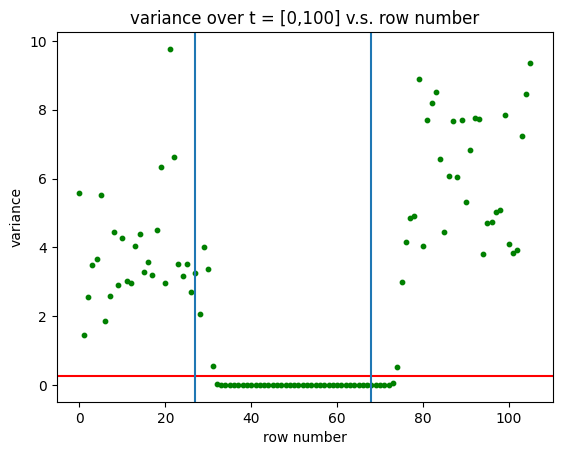

In [33]:
file = open(rough_coordinates_file, 'a')

rough_coords = []
for i in tqdm(range(len(images))):
    margin = 0
    window_size = 100
    if i % window_size == 0:
        variances = np.var(padded_distances[i:i+window_size,:],axis=0)

        start, end = find_low_center_interval(variances)
        start = start-5
        end = end-5
        if i == 0:
            plt.scatter(range(variances.shape[0]),variances,s=10,color='green')
            plt.axhline(0.25,color='red')
            plt.axvline(start)
            plt.axvline(end)
            plt.xlabel('row number')
            plt.ylabel('variance')
            plt.title('variance over t = [0,100] v.s. row number')
        print(f'i = {i}, start = {start}, end = {end}')
    start_rescaled = int(coords3[i].shape[1]*start/max_length*(1+margin))
    end_rescaled = int(coords3[i].shape[1]*end/max_length*(1-margin))
    coords4 = coords3[i][:,start_rescaled:end_rescaled]
    coords4 = np.array([perspective_transform_point(mser_sd_points[i][0], mser_sd_points[i][1], [coords4[0,j],coords4[1,j]]) for j in range(coords4.shape[1])]).T
    rough_coords.append(coords4)
    for j, (x, y) in enumerate(coords4.T):
        file.write(f"{i}\t{j}\t{x}\t{y}\t0\n")


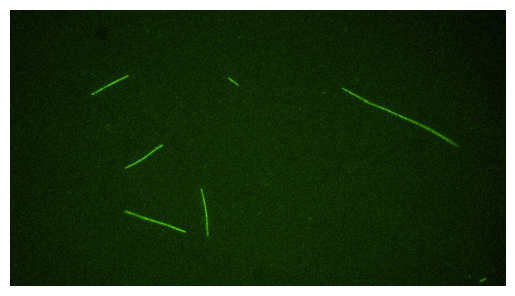

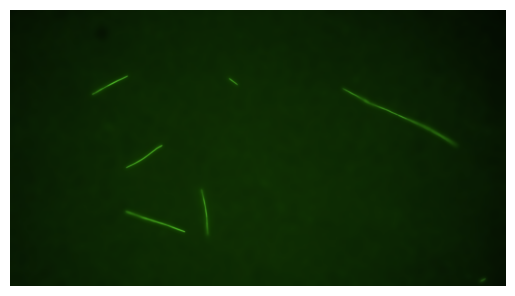

In [21]:
plt.axis('off')
plt.imshow(raw_images[1])

plt.show()
plt.axis('off')
plt.imshow(images_uncropped[1])

/tmp/ipykernel_1729608/2735598804.py:24: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


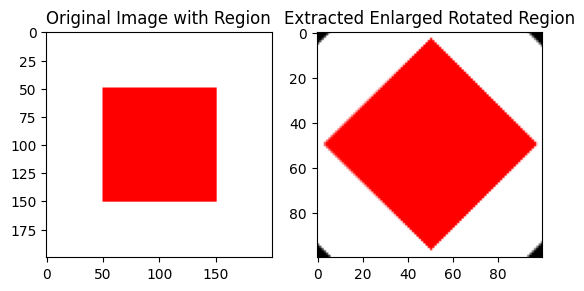

In [224]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def enlarge_bounding_box(region, e=2):
    x, y, w, h = cv2.boundingRect(region)
    cx, cy = x + w / 2, y + h / 2
    w_enlarged, h_enlarged = w * e, h * e
    x_new, y_new = int(cx - w_enlarged / 2), int(cy - h_enlarged / 2)
    w_new, h_new = int(w_enlarged), int(h_enlarged)
    return (x_new, y_new, w_new, h_new)

def extract_rotated_region(image, region, angle, e=2):
    x, y, w, h = enlarge_bounding_box(region, e)
    enlarged_region = np.zeros_like(region)
    enlarged_region[y:y+h, x:x+w] = region[y:y+h, x:x+w]
    points = np.column_stack(np.where(enlarged_region > 0))
    rect = cv2.minAreaRect(points)
    box = cv2.boxPoints(((rect[0][0], rect[0][1]), (rect[1][0], rect[1][1]), angle))

    center = np.mean(box, axis=0)
    box = e * (box - center) + center

    box = np.int0(box)
    width, height = int(rect[1][0]), int(rect[1][1])
    src_pts = box.astype("float32")
    dst_pts = np.array([[0, height-1], [0, 0], [width-1, 0], [width-1, height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    return cv2.warpPerspective(image, M, (width, height))

# Example usage with visualization
image = np.full((200, 200, 3), 255, dtype=np.uint8)
cv2.rectangle(image, (50, 50), (150, 150), (0, 0, 255), -1)
region = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(region, (50, 50), (150, 150), 255, -1)
angle = 45
extracted_region = extract_rotated_region(image, region, angle, e=1.5)

plt.subplot(1, 2, 1)
plt.title("Original Image with Region")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title("Extracted Enlarged Rotated Region")
plt.imshow(cv2.cvtColor(extracted_region, cv2.COLOR_BGR2RGB))
plt.show()

import numpy as np

# Example box (4 corners of a rotated rectangle)
box = np.array([
    [100, 50],
    [200, 50],
    [200, 175],
    [100, 175]
])




59.03623962402344
(1302, 2)


/tmp/ipykernel_7793/1817469705.py:20: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


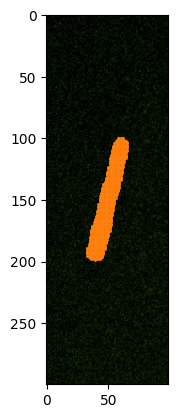

In [8]:
import matplotlib.pyplot as plt
import math

def enlarge_bounding_box(region, e=2):
    x, y, w, h = cv2.boundingRect(region)
    cx, cy = x + w / 2, y + h / 2
    w_enlarged, h_enlarged = w * e, h * e
    x_new, y_new = int(cx - w_enlarged / 2), int(cy - h_enlarged / 2)
    w_new, h_new = int(w_enlarged), int(h_enlarged)
    
    return (x_new, y_new, w_new, h_new)

def extract_rotated_region(image, region, angle, e=2):
    x, y, w, h = enlarge_bounding_box(region, e)
    enlarged_region = np.zeros_like(region)
    enlarged_region[y:y+h, x:x+w] = region[y:y+h, x:x+w]
    points = np.column_stack(np.where(enlarged_region > 0))
    rect = cv2.minAreaRect(points)
    box = cv2.boxPoints(((rect[0][0], rect[0][1]), (rect[1][0], rect[1][1]), angle))
    box = np.int0(box)
    width, height = int(rect[1][0]), int(rect[1][1])
    src_pts = box.astype("float32")
    dst_pts = np.array([[0, height-1], [0, 0], [width-1, 0], [width-1, height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    return cv2.warpPerspective(image, M, (width, height))

def process_box(image, raw_image, original_image = None, n = 20, past_regions = None, factor = 2):


    gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    image_area = image.shape[0]*image.shape[1]
    mser = cv2.MSER_create(delta=2, min_area=image_area//64, max_area=image_area//8, max_variation=1, min_diversity=0.1)

    regions, _ = mser.detectRegions(gray)

    if past_regions is not None:
        regions = sorted(regions, key=lambda region : sum_intersections(region, past_regions), reverse=True)
    else:
        regions = sorted(regions, key=cv2.contourArea, reverse=True)

    if len(regions) == 0:
         regions = past_regions
    #nonrotated
    x, y, w, h = enlarge_bounding_box(regions[0], e = factor)
    result = raw_image[bbox[0]+y:bbox[0]+y+h,bbox[2]+x:bbox[2]+x+w,:]
    #get slope
    hull = cv2.convexHull(regions[0].reshape(-1, 1, 2))
    cv2.drawContours(result, [hull], 0, (0, 0, 255), 1)
    aux_image = np.zeros_like(gray)
    cv2.fillPoly(aux_image, [regions[0]], 255)
    coords = track_image(aux_image)
    
    print(angle)

    mask = np.zeros(raw_image.shape[0:1], dtype=np.uint8)
    cv2.fillPoly(mask, [regions[0].astype(np.int32)], 255)
    test = extract_rotated_region(raw_image,regions[0],angle,e=2)

    print(regions[0].shape)
    return result, regions[:n], (bbox[0]+y,bbox[0]+y+h,bbox[2]+x,bbox[2]+x+w),coords, regions[0]

result, regions, bounding, coords, distinguished_region = process_box(images[1083],raw_images[1083],factor=3)

plt.imshow(result)
plt.scatter(coords[:,1]-np.full(coords.shape[0],bounding[2]-bbox[2]),coords[:,0]-np.full(coords.shape[0],bounding[0]-bbox[0]),s=1)
plt.scatter(distinguished_region[:,0]-np.full(distinguished_region.shape[0],bounding[2]-bbox[2]),distinguished_region[:,1]-np.full(distinguished_region.shape[0],bounding[0]-bbox[0]),s=1)


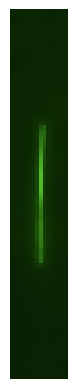

In [ ]:
num = 1
plt.axis('off')
plt.scatter(coords3[num][0,33:73],coords3[num][1,33:73],s=1,color='r')
plt.imshow(mser_images[num])


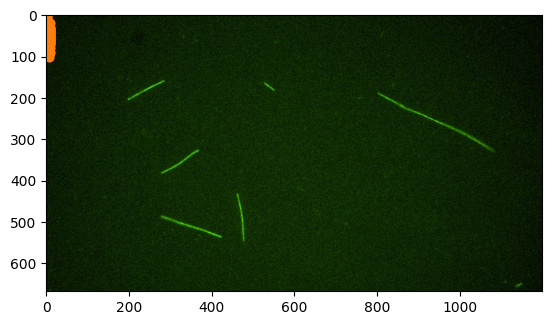

In [21]:
warped = np.array([perspective_transform_point(mser_sd_points[num][0], mser_sd_points[num][1], [rough_coords[num][0,j],rough_coords[num][1,j]]) for j in range(rough_coords[num].shape[1])]).T
plt.scatter(warped[0,:],warped[1,:],s=1)
plt.scatter(coords3[num][0,:],coords3[num][1,:])
plt.imshow(raw_images[num])